In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

              age        year  nodes_detected  survival_status
count  306.000000  306.000000      306.000000       306.000000
mean    52.457516   62.852941        4.026144         1.264706
std     10.803452    3.249405        7.189654         0.441899
min     30.000000   58.000000        0.000000         1.000000
25%     44.000000   60.000000        0.000000         1.000000
50%     52.000000   63.000000        1.000000         1.000000
75%     60.750000   65.750000        4.000000         2.000000
max     83.000000   69.000000       52.000000         2.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              306 non-null    int64
 1   year             306 non-null    int64
 2   nodes_detected   306 non-null    int64
 3   survival_status  306 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB
None


NameError: name 'X_train' is not defined

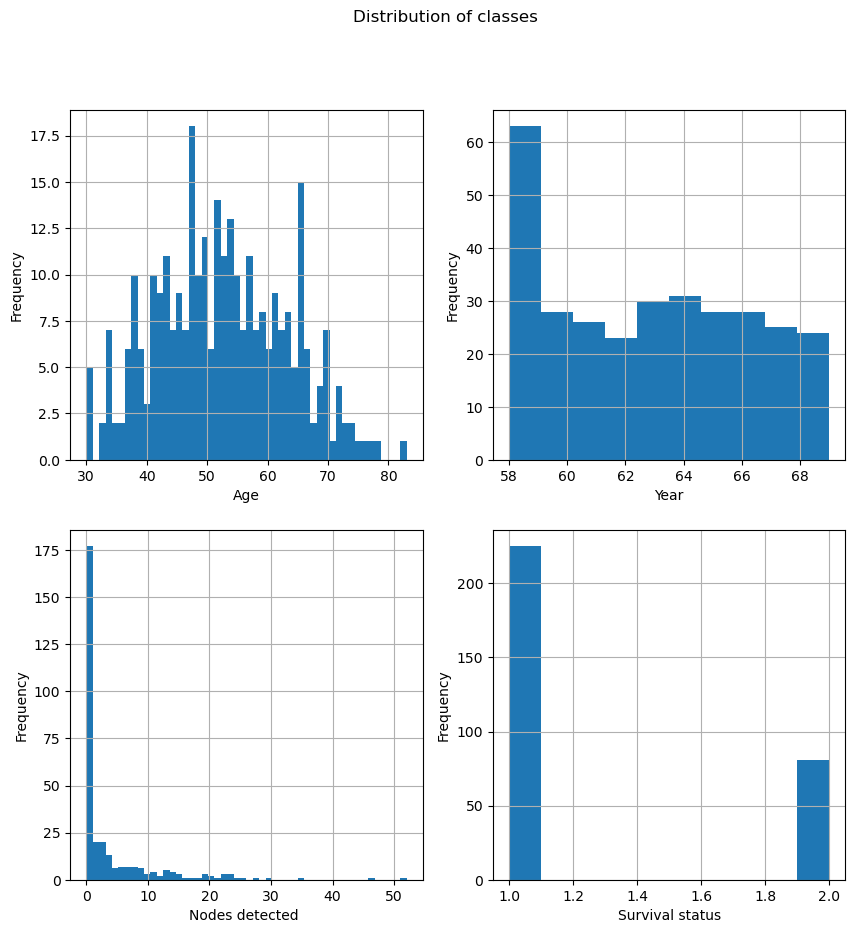

In [6]:
data = pd.read_csv(
        "haberman.csv",
        header=None,
        names=["age", "year", "nodes_detected", "survival_status"],
    )
 
print(data.describe())
print(data.info())

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
fig.suptitle("Distribution of classes")
#Plot distributions
data["age"].hist(ax=ax[0,0], bins=50)
data["year"].hist(ax=ax[0,1])
data["nodes_detected"].hist(ax=ax[1,0], bins=50)
data["survival_status"].hist(ax=ax[1,1])

#Visualize plots
ax[0,0].set_xlabel("Age")
ax[0,0].set_ylabel("Frequency")
ax[0,1].set_xlabel("Year")
ax[0,1].set_ylabel("Frequency")
ax[1,0].set_xlabel("Nodes detected ")
ax[1,0].set_ylabel("Frequency")
ax[1,1].set_xlabel("Survival status")
ax[1,1].set_ylabel("Frequency")

fig.savefig("data_dist_cancer.svg", format='svg')


pca = PCA(n_components=2)
# Apply PCA directly to the training features, assuming they are already scaled
X_train_pca = pca.fit_transform(X_train) 

# 4. Calculate Explained Variance
evr = pca.explained_variance_ratio_
print(f"Explained Variance Ratio by Component: {evr}")
print(f"Total Explained Variance (2D): {np.sum(evr):.2%}")

# 5. Visualization
plt.figure(figsize=(8, 6))

# Scatter plot for Class 0 (Survived)
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], 
            color='#1f77b4', alpha=0.6, label='Died (0)')

# Scatter plot for Class 1 (Died)
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], 
            color='#ff7f0e', alpha=0.7, label='Survived (1)')

plt.title('PCA of Haberman Dataset (2 Components)')
plt.xlabel(f'Principal Component 1 ({evr[0]:.1%} Var)')
plt.ylabel(f'Principal Component 2 ({evr[1]:.1%} Var)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("PCA_haberman.svg", format='svg')
plt.show()



In [7]:
# Load and preprocess data
def Normalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X = (X-mu)/sigma
    return X                       # TODO: Implement the normalization function


def load_data():
    # url_hospital = "https://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"
    data = pd.read_csv(
        "haberman.csv",
        header=None,
        names=["age", "year", "nodes_detected", "survival_status"],
    )
    X = data.iloc[:, :3].to_numpy()
    y = (data.iloc[:, 3] == 1).astype(int)  # Convert survival status to binary
    X = Normalize(X)

    return X, y

# Validate Normalize fucntion

X, y = load_data()
X_mean = np.mean(X, axis=0)
X_var = np.var(X, axis=0)

print(f"Validation nomalization: mean = " + str(X_mean)+", Var=" + str(X_var))



Validation nomalization: mean = [1.39322105e-16 3.88940877e-16 2.61228947e-17], Var=[1. 1. 1.]


In [8]:
# Logistic function
def sigmoid(x):
    x = 1/(1+np.exp(-x))
    return x            # TODO: Implement the sigmoid function

# Test
sig_val = sigmoid(0)
print(f"Expected = 1/2, sigmoid(0) = {sig_val:.2f}" )

# Negative Log-Likelihood
def nll(beta, X, y):  # Input name changed to y_true
    
    z = X @ beta 
    y_pred = sigmoid(z) 
    
    nnl = -np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    
    return nnl                  # TODO: Implement NLL function


# Gradient of NLL
def gradient(beta, X, y):
    z = X @ beta
    y_pred = sigmoid(z)
    gradient = X.T @ (y_pred - y)
    return gradient     # TODO: Implement the gradient of NLL?

grad = gradient(np.array([1,1]), np.array([[1,1]]), np.array([1]))
print(f"----Testing gradient shape----\nExpected shape: (2,)\nFunciton shape: " + str(grad.shape))
print(f"----Testing gradient values----\nExpected values: (-0.1192, 0.1192)\nValues = " + str(grad))

# Hessian of NLL
def hessian(beta, X):
    z = X @ beta
    y_pred = sigmoid(z)
    R = y_pred * (1-y_pred)
    dimension = len(y_pred)
    RR = np.eye(dimension, dimension) * R
    hessian = X.T @ RR @ X
    return hessian       # TODO: Implement the hessian of NLL

hess = hessian(np.array([1,1]), np.array([[1,1], [1,1]]))
print("----Testing hessian----\nExpected shape: (2,2)\nShape: " + str(hess.shape))

Expected = 1/2, sigmoid(0) = 0.50
----Testing gradient shape----
Expected shape: (2,)
Funciton shape: (2,)
----Testing gradient values----
Expected values: (-0.1192, 0.1192)
Values = [-0.11920292 -0.11920292]
----Testing hessian----
Expected shape: (2,2)
Shape: (2, 2)


In [9]:
def levenberg_marquardt_reg(H, delta=10e-6):
    eigenvalues = np.linalg.eigvalsh(H)
    min_eig = np.min(eigenvalues)
    lambda_reg = max(0, -min_eig) + delta
    H = H + np.eye(H.shape[0]) * lambda_reg
    return H

# Newton-Raphson optimization
def newton_raphson(X, y, tol=1e-6, max_iter=100):
    beta = np.zeros(X.shape[1])  # TODO: Implement the Newton-Raphson optimization
    iter_tol = 1
    iter = 0
    while iter <= max_iter:
        H = hessian(beta, X)
        grad = gradient(beta, X, y)
        det =  np.abs(np.linalg.det(H))
        if det < tol:
            H = levenberg_marquardt_reg(H)
        H_inverse = np.linalg.inv(H)   
        beta_next = beta - H_inverse @ grad
        iter += 1
        #iter_tol = np.linalg.norm(beta_next-beta)
        
        beta = beta_next
    beta = beta_next
        
    return beta

In [10]:
def predict(X, beta):
    z = X @ beta
    prediction = sigmoid(z)
    condition = prediction > 0.5
    prediction = np.where(condition, 1, 0)
    
    return prediction    # TODO: Implement the prediction function

Newton Raphson Accuracy: 0.66
Newton Raphson Precision: 0.79
Newton Raphson Recall: 0.70
Newton Raphson F1 Score: 0.75


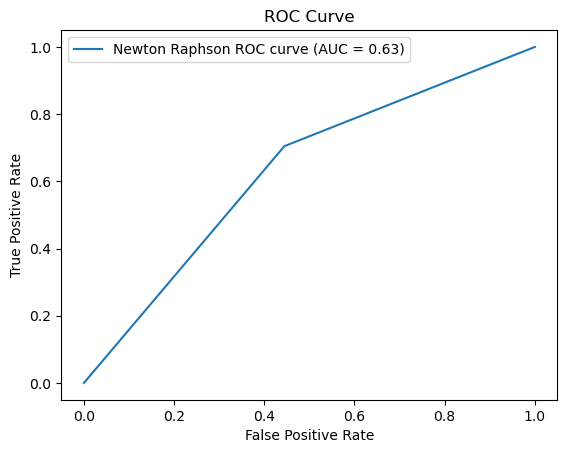

Max difference: 1.2448673203380167e-09


In [14]:
# Main workflow

# Load and preprocess data
X, y = load_data()

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2)

# Train logistic regression model
beta = newton_raphson(X_train, y_train)

# Predictions and evaluation metrics for Newton Raphson
NP_preds = predict(X_test, beta)
NP_accuracy = accuracy_score(y_test, NP_preds)
NP_precision = precision_score(y_test, NP_preds)
NP_recall = recall_score(y_test, NP_preds)
NP_f1 = f1_score(y_test, NP_preds)

# Print metrics
print(f"Newton Raphson Accuracy: {NP_accuracy:.2f}")
print(f"Newton Raphson Precision: {NP_precision:.2f}")
print(f"Newton Raphson Recall: {NP_recall:.2f}")
print(f"Newton Raphson F1 Score: {NP_f1:.2f}")


fpr, tpr, _ = roc_curve(y_test, NP_preds)

roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"Newton Raphson ROC curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
epsilon = 1e-5
grad_approx = np.zeros_like(beta)

for i in range(len(beta)):
    beta_eps = beta.copy()
    beta_eps[i] += epsilon
    loss_plus = nll(beta_eps, X, y)
    
    beta_eps[i] -= 2*epsilon
    loss_minus = nll(beta_eps, X, y)
    
    grad_approx[i] = (loss_plus - loss_minus) / (2*epsilon)

# Correct: function is called gradient
grad_analytic = gradient(beta, X, y)
print("Max difference:", np.max(np.abs(grad_analytic - grad_approx)))


In [ ]:
# Train logistic regression model using sklearn
logreg = LogisticRegression(fit_intercept=True, penalty=None, solver="lbfgs")
logreg.fit(X_train, y_train)

# Predictions and evaluation metrics for Scikit Learn
SC_preds = logreg.predict(X_test)
SC_accuracy = accuracy_score(y_test, SC_preds)
SC_precision = precision_score(y_test, SC_preds)
SC_recall = recall_score(y_test, SC_preds)
SC_f1 = f1_score(y_test, SC_preds)
# Print metrics
print(f"Scikit Learn Accuracy: {SC_accuracy:.2f}")
print(f"Scikit Learn Precision: {SC_precision:.2f}")
print(f"Scikit Learn Recall: {SC_recall:.2f}")
print(f"Scikit Learn F1 Score: {SC_f1:.2f}")

Scikit Learn Accuracy: 0.74
Scikit Learn Precision: 0.75
Scikit Learn Recall: 0.98
Scikit Learn F1 Score: 0.85


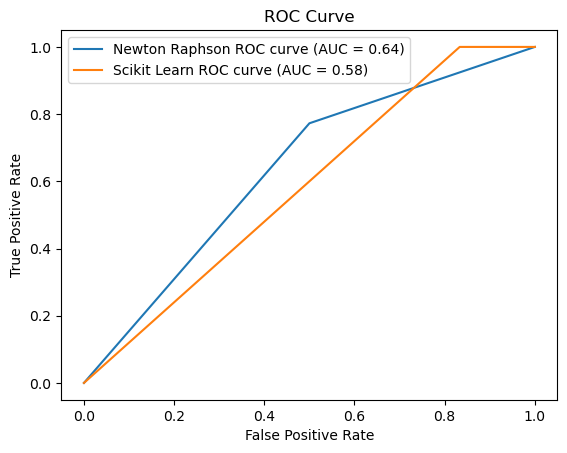

In [ ]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, NP_preds)
fpr2, tpr2, _ = roc_curve(y_test, SC_preds)
roc_auc = auc(fpr, tpr)
roc_auc2 = auc(fpr2, tpr2)
plt.plot(fpr, tpr, label=f"Newton Raphson ROC curve (AUC = {roc_auc:.2f})")
plt.plot(fpr2, tpr2, label=f"Scikit Learn ROC curve (AUC = {roc_auc2:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("ROC_curve.svg", format='svg')
plt.show()


In [ ]:
print("----Weights of Newton method----\n" + str(beta))
print("----Weights of scikit-learn----\n" + str(logreg.coef_.flatten()))

----Weights of Newton method----
[-0.06472189  0.02391457 -0.7303241 ]
----Weights of scikit-learn----
[-0.10513545 -0.00841301 -0.65663797]
